# Predicting grapevine leaf venation from blade geometry (Euler Characteristic Transform)

Reproduction of the vein-prediction pipeline of:

> **The Euler Characteristic Transform Enables Classification of Complex Plant Shapes and Prediction of Leaf Venation from Blade Geometry** — bioRxiv preprint v1 (April 2026), doi:[10.64898/2026.04.13.718293](https://doi.org/10.64898/2026.04.13.718293)

Author code: [`yemeen/ectnet`](https://github.com/yemeen/ectnet) @ commit `9cdff8d6d2f4f60489c192ada1b92d198eceae48`, directory `synthetic_vein_prediction/` (scripts 1–3, used verbatim where possible).

**Scope — partial demonstration (not the full paper).** This notebook reproduces the paper's *Figure 7* subsection:
1. Generate **synthetic grapevine leaves** (blade + vein coordinates) from the authors' bundled GPA/PCA model of real grapevine leaves, using their SMOTE-like interpolation in PCA space.
2. Render each leaf as a **radial ECT image** (360 directions × 360 thresholds, 256×256) plus blade mask and ground-truth vein mask.
3. Train the authors' **two-channel U-Net** (blade ECT + blade mask → vein mask) and evaluate predictions with the paper's TP/FP/FN color scheme.

**Execution status:** this notebook is executed on Google Colab; all data downloads and scientific computation run inside this notebook.

**Japanese summary (日本語的要約):** このノートブックは、ブドウの葉身幾何（radial ECT 画像 + 葉身マスク）から葉脈マスクを予測する U-Net 学習パイプライン（論文 Figure 7 相当）を再現します。著者提供の GPA/PCA モデル（リポジトリ同梱）から SMOTE 的な補間で合成葉を生成し、ECT を計算して学習します。

> ⚠️ **License note:** the `ectnet` repository currently declares **no LICENSE**. This notebook runs the authors' code for educational reproduction and does not redistribute it.

> ⚠️ **AI adaptation note:** cells 5–9 copy the authors' pinned code nearly verbatim, with a few documented runtime-boundary adaptations (marked `# ADAPTATION:` in comments). Any untested behavior beyond the executed example is not guaranteed. / **AIによる翻訳・改変の注記:** 著者コードの一部を本ノートブック用に最小限改変しています（改変箇所にはコメントを付記）。実行例以外の挙動は保証されません。

## Runtime selection (run on **GPU / T4**)

**Runtime → "Change runtime type" → T4 GPU.** The U-Net training here is the GPU path; the authors' device selection (`cuda` → `cpu`) is preserved, so a CPU runtime will *run* but is much slower (estimated tens of minutes) and is not the validated configuration for this notebook.

Expected duration on T4: roughly 10–20 minutes end-to-end (installs + synthetic-leaf generation + reduced training + figures). Downloads: ~6 MB of input data plus pip packages.

**Japanese:** 上部メニューの「ランタイム」→「ランタイムのタイプを変更」で **T4 GPU** を選択してから実行してください。CPU でも動作しますが大幅に遅くなります。

In [ ]:
import torch, platform
print("Python:", platform.python_version())
print("torch:", torch.__version__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("WARNING: no GPU allocated. Training will be very slow; select a T4 GPU runtime for the intended experience.")

Python: 3.13.15
torch: 2.11.0+cu130
Device: cuda


## 1. Dependencies

The pipeline needs the authors' `ect` library (PyPI package [`ect`](https://pypi.org/project/ect/), v1.3.0 — the version pinned in the repo's `pyproject.toml`), OpenCV (for one affine fit), plus h5py/scikit-learn which Colab already provides. The `ect` package uses Numba JIT on first use.

**Japanese:** 著者の `pyproject.toml` が pin する `ect>=1.3.0` と OpenCV（アフィン変換推定に使用）をインストールします。`ect` は初回呼び出し時に Numba の JIT コンパイルを行います。

In [ ]:
%pip -q install "ect>=1.3.0" opencv-python-headless
import ect, cv2, h5py, sklearn
print("ect:", ect.__version__ if hasattr(ect, "__version__") else "installed")
print("opencv:", cv2.__version__)
print("h5py:", h5py.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 3.2 MB/s eta 0:00:00


ect: installed
opencv: 4.14.0
h5py: 3.14.0


## 2. Input data — the authors' bundled GPA/PCA model of real grapevine leaves

The full pipeline's step 0 (`0_morphometric_leaf_processing.ipynb`) fits a GPA + PCA model to real grapevine blade+vein landmarks (Chitwood et al. 2024 data, bundled as `data.zip`). The repository also commits the **fitted model outputs** in `outputs/saved_leaf_model_data/`, which is exactly what script 1 consumes — so this notebook downloads those two HDF5 files from the pinned commit instead of re-running the 793 KB step-0 notebook.

Files (pinned raw URLs, verified by size and Git blob SHA-1):
- `synthetic_vein_prediction/outputs/saved_leaf_model_data/leaf_pca_model_parameters.h5` — 5,442,610 bytes, blob `a219a31785033910e2c3ce7ee9cb68f15a5a5d57` (keys: `components`, `mean`, `explained_variance`; attr `n_components`)
- `synthetic_vein_prediction/outputs/saved_leaf_model_data/original_pca_scores_and_geno_labels.h5` — 344,912 bytes, blob `e520022f05b20c9a31d7a46260dbe8c53cb87152` (keys: `pca_scores`, `geno_labels`)

**Japanese:** ステップ0（GPA+PCA 学習）の**学習済み出力**をリポジトリからピンしたコミットで直接取得します（サイズと Git blob SHA-1 で検証）。生のランドマーク `data.zip` は不要です。

In [ ]:
import hashlib, urllib.request
from pathlib import Path

COMMIT = "9cdff8d6d2f4f60489c192ada1b92d198eceae48"
BASE = f"https://raw.githubusercontent.com/yemeen/ectnet/{COMMIT}/synthetic_vein_prediction/outputs/saved_leaf_model_data"
DATA_DIR = Path("/content/ectnet_run/saved_leaf_model_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "leaf_pca_model_parameters.h5": (5442610, "a219a31785033910e2c3ce7ee9cb68f15a5a5d57"),
    "original_pca_scores_and_geno_labels.h5": (344912, "e520022f05b20c9a31d7a46260dbe8c53cb87152"),
}

def git_blob_sha1(path):
    data = Path(path).read_bytes()
    return hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()

for fname, (size, blob) in FILES.items():
    dest = DATA_DIR / fname
    if not dest.exists():
        urllib.request.urlretrieve(f"{BASE}/{fname}", dest)  # pinned commit URL
    actual_size, actual_blob = dest.stat().st_size, git_blob_sha1(dest)
    assert actual_size == size and actual_blob == blob, f"Integrity check failed for {fname}"
    print(f"OK {fname}: {actual_size} bytes, blob {actual_blob[:12]}...")

OK leaf_pca_model_parameters.h5: 5442610 bytes, blob a219a3178503...
OK original_pca_scores_and_geno_labels.h5: 344912 bytes, blob e520022f05b2...


### Inspect the latent-space model

Verify the HDF5 structure against the loader in script 1 (`load_pca_model_data`): component/mean dimensions must match the 3344-dim flattened coordinate space (1216 vein + 456 blade = 1672 points × 2), and the genotype labels define the SMOTE classes. The genotype class count is printed here because it is only visible inside the data.

**Japanese:** HDF5 の内容を著者ローダーの期待（3344 次元の座標空間、遺伝型ラベル）と照合します。クラス数はデータ内部でのみ確認できるため、ここで表示します。

In [ ]:
import h5py, numpy as np

with h5py.File(DATA_DIR / "leaf_pca_model_parameters.h5", "r") as f:
    components, mean = f["components"][:], f["mean"][:]
    explained_variance, n_components = f["explained_variance"][:], f.attrs["n_components"]
with h5py.File(DATA_DIR / "original_pca_scores_and_geno_labels.h5", "r") as f:
    pca_scores = f["pca_scores"][:]
    geno_labels = np.array([s.decode("utf-8") for s in f["geno_labels"][:]])

print("components:", components.shape, "| mean:", mean.shape)
print("n_components attr:", n_components, "| explained_variance:", explained_variance.shape)
print("original PCA scores:", pca_scores.shape, "->", pca_scores.shape[0], "real leaves")
classes, counts = np.unique(geno_labels, return_counts=True)
print(f"{len(classes)} genotype classes:", dict(zip(classes.tolist(), counts.tolist())))
assert components.shape[1] == 1672 * 2 == 3344, "unexpected coordinate space" 

components: (210, 3344) | mean: (3344,)
n_components attr: 210 | explained_variance: (210,)
original PCA scores: (210, 210) -> 210 real leaves
5 genotype classes: {'algeria': 71, 'dissected': 11, 'rootstock': 25, 'vinifera': 38, 'wild': 65}


### Preview: reconstruct real leaves from the latent space

Before generating synthetic leaves, reconstruct a few **real** leaves by inverse-transforming their original PCA scores, and draw blade (outline) and vein (lines) coordinates. This previews the actual bundled data and the blade/vein coordinate layout the pipeline operates on (first 1216 points = vein, last 456 = blade, per script 1's `NUM_VEIN_COORDS`/`NUM_BLADE_COORDS`).

**Japanese:** 合成葉を生成する前に、元の PCA スコアから**実葉**を再構成して表示します（先頭 1216 点が葉脈、末尾 456 点が葉身）。同梱データの確認です。

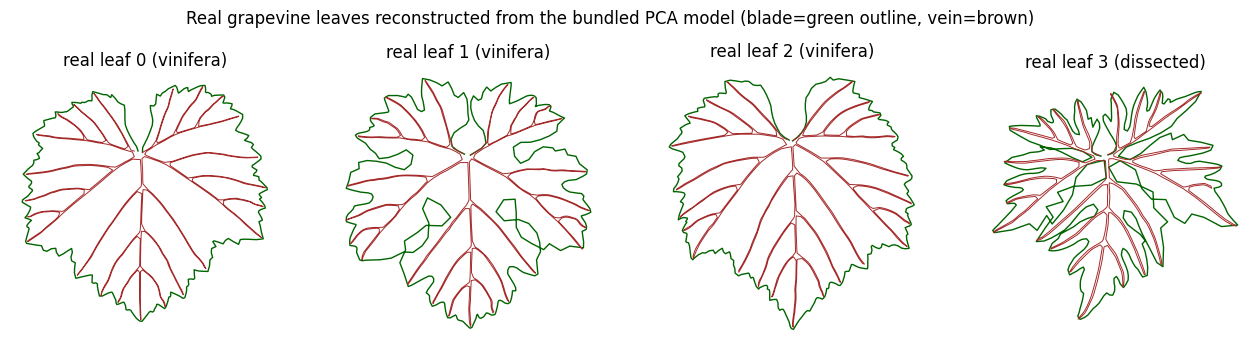

algeria      71
wild         65
vinifera     38
rootstock    25
dissected    11


In [ ]:
import matplotlib.pyplot as plt

def split_coords(flat):
    c = flat.reshape(1672, 2)
    return c[:1216], c[1216:]  # vein, blade

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, idx in zip(axes, [0, 1, 2, 3]):
    vein, blade = split_coords(np.dot(pca_scores[idx], components) + mean)
    ax.plot(blade[:, 0], blade[:, 1], "-", color="darkgreen", lw=1)
    ax.plot(vein[:, 0], vein[:, 1], "-", color="brown", lw=0.7)
    ax.set_title(f"real leaf {idx} ({geno_labels[idx]})")
    ax.set_aspect("equal"); ax.axis("off")
plt.suptitle("Real grapevine leaves reconstructed from the bundled PCA model (blade=green outline, vein=brown)")
plt.show()
import pandas as pd
print(pd.Series(geno_labels).value_counts().to_string())

## 3. Synthetic leaf generation — authors' script 1 (ported)

The next three cells port `1_generate_synthetic_leaves.py` (verbatim helpers; the output bookkeeping is trimmed to what scripts 2–3 consume). The pipeline per synthetic leaf:

1. **SMOTE-like sampling** in PCA space: pick a random real leaf, find its k=5 nearest neighbors **within the same genotype class**, interpolate with random α, repeat to a per-class target (author default 400/class).
2. Inverse-transform to 3344-dim coordinates, split into vein/blade, apply a **random rotation ±180°**.
3. Compute the **radial ECT** of the blade via the `ect` package (`EmbeddedGraph.add_cycle` → center/transform/scale to `BOUND_RADIUS=1`; 360 directions × 360 thresholds), derive the affine matrix that maps the rotated raw coordinates into the ECT's normalized frame, and rasterize 256×256 blade mask, **vein mask (aligned to the blade ECT frame)** and blade ECT image.

**ADAPTATION:** to bound Colab runtime, the per-class target is capped so that **≈480 leaves total** are generated (author: 400 per class), and the per-leaf *vein ECT* + combined QC visualizations (unused by scripts 2–3) are skipped. Seed 42 and all ECT/rasterization parameters are the authors'. Each leaf still uses the author's per-leaf seed `42 + i`.

**Japanese:** 著者の script 1 をほぼそのまま移植します。PCA 空間での SMOTE 的補間 → ランダム回転 → radial ECT 計算 → マスク/ECT 画像のラスタライズ。実行時間確保のため合成枚数を約 480 枚（著者: クラスごと 400 枚）に制限し、script 2/3 で使わない葉脈 ECT と QC 図の生成を省略しています（シード 42、他のパラメータは著者値のまま）。

In [ ]:
# --- Ported helpers from yemeen/ectnet @ 9cdff8d6 synthetic_vein_prediction/scripts/1_generate_synthetic_leaves.py ---
import numpy as np, pandas as pd, cv2, shutil, os
from pathlib import Path
from PIL import Image, ImageDraw
from ect import ECT, EmbeddedGraph
from sklearn.neighbors import NearestNeighbors

BOUND_RADIUS = 1
NUM_ECT_DIRECTIONS = 360
ECT_THRESHOLDS = np.linspace(0, BOUND_RADIUS, NUM_ECT_DIRECTIONS)
IMAGE_SIZE = (256, 256)
GLOBAL_RANDOM_SEED = 42
NUM_VEIN_COORDS = 1216
NUM_BLADE_COORDS = 456
TOTAL_COORDS = NUM_VEIN_COORDS + NUM_BLADE_COORDS
FLATTENED_COORD_DIM = TOTAL_COORDS * 2
MASK_BACKGROUND_GRAY, MASK_BLADE_GRAY, MASK_VEIN_GRAY = 0, 255, 255

def apply_transformation_with_affine_matrix(points, affine_matrix):
    if points.size == 0:
        return np.array([])
    points_homogeneous = np.hstack((points, np.ones((points.shape[0], 1))))
    return (points_homogeneous @ affine_matrix.T)[:, :2]

def find_robust_affine_transformation_matrix(src_points, dst_points):
    chosen_src_pts, chosen_dst_pts = [], []
    indices = np.arange(len(src_points))
    num_attempts = min(len(src_points) * (len(src_points) - 1) * (len(src_points) - 2) // 6, 1000)
    for _ in range(num_attempts):
        selected_indices = np.random.choice(indices, 3, replace=False)
        p1_src, p2_src, p3_src = src_points[selected_indices]
        p1_dst, p2_dst, p3_dst = dst_points[selected_indices]
        area_val = (p1_src[0] - p3_src[0]) * (p2_src[1] - p1_src[1]) - \
                   (p1_src[0] - p2_src[0]) * (p3_src[1] - p1_src[1])
        if np.abs(area_val) > 1e-6:
            chosen_src_pts = np.float32([p1_src, p2_src, p3_src])
            chosen_dst_pts = np.float32([p1_dst, p2_dst, p3_dst])
            break
    if len(chosen_src_pts) < 3:
        raise ValueError("Could not find 3 non-collinear points for affine transformation.")
    M_2x3 = cv2.getAffineTransform(chosen_src_pts, chosen_dst_pts)
    return np.vstack([M_2x3, [0, 0, 1]])

def ect_coords_to_pixels(coords_ect, image_size, bound_radius):
    display_x_conceptual = coords_ect[:, 1]
    display_y_conceptual = coords_ect[:, 0]
    scale_factor = image_size[0] / (2 * bound_radius)
    offset_x, offset_y = image_size[0] / 2, image_size[1] / 2
    pixel_x = (display_x_conceptual * scale_factor + offset_x).astype(int)
    pixel_y = (-display_y_conceptual * scale_factor + offset_y).astype(int)
    return np.column_stack((pixel_x, pixel_y))

def save_grayscale_shape_mask(transformed_coords, pixel_identity, save_path):
    img = Image.new("L", IMAGE_SIZE, MASK_BACKGROUND_GRAY)
    draw = ImageDraw.Draw(img)
    fill_color = MASK_BLADE_GRAY if pixel_identity == 1 else MASK_VEIN_GRAY
    if transformed_coords is not None and transformed_coords.size > 0:
        pixel_coords = ect_coords_to_pixels(transformed_coords, IMAGE_SIZE, BOUND_RADIUS)
        if len(pixel_coords) >= 3:
            draw.polygon([(int(p[0]), int(p[1])) for p in pixel_coords], fill=fill_color)
        else:
            for x, y in pixel_coords:
                if 0 <= x < IMAGE_SIZE[0] and 0 <= y < IMAGE_SIZE[1]:
                    draw.point((x, y), fill=fill_color)
    img.save(save_path)

def save_radial_ect_image(ect_result, save_path, cmap_name="gray"):
    if ect_result is None:
        Image.new("L", IMAGE_SIZE, 0).save(save_path)
        return
    fig, ax = plt.subplots(subplot_kw=dict(projection="polar"),
                           figsize=(IMAGE_SIZE[0]/100, IMAGE_SIZE[1]/100), dpi=100)
    thetas, thresholds = ect_result.directions.thetas, ect_result.thresholds
    THETA, R = np.meshgrid(thetas, thresholds)
    ax.pcolormesh(THETA, R, ect_result.T, cmap=cmap_name)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rlim([0, BOUND_RADIUS])
    ax.axis("off")
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0, dpi=100)
    plt.close(fig)

def rotate_coords_2d(coords, angle_deg):
    angle_rad = np.deg2rad(angle_deg)
    rot_matrix = np.array([[np.cos(angle_rad), -np.sin(angle_rad)],
                           [np.sin(angle_rad),  np.cos(angle_rad)]])
    return coords @ rot_matrix.T

print("ECT helpers ready (ported from script 1).")

ECT helpers ready (ported from script 1).


### Generate the synthetic dataset

Instantiate the authors' `ect` calculator (360 directions × 360 thresholds, bound radius 1), run the SMOTE-like sampling with seed 42, and process every synthetic leaf: random rotation, blade ECT, blade mask, vein mask in the blade ECT frame, and transformed blade coordinates for the outline overlay. Per-leaf failures are recorded and skipped, exactly like the author script. First Numba JIT calls may take a short while.

**Japanese:** `ect` 計算機を初期化し（360 方向 × 360 閾値、半径 1）、seed 42 で SMOTE 的サンプリングを行い、各合成葉ごとにランダム回転 → 葉身 ECT → 葉身/葉脈マスク → 座標保存を処理します。失敗した個体は著者スクリプト同様にスキップされます。

In [ ]:
# --- SMOTE-like generation in PCA space and per-leaf processing (ported from script 1) ---
def generate_synthetic_pca_samples(pca_data, samples_per_class_target, k_neighbors, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)
    original_pca_scores = pca_data["original_pca_scores"]
    original_geno_labels = pd.Series(pca_data["original_geno_labels"])
    synthetic_X_pca, synthetic_y = [], []
    all_classes = original_geno_labels.value_counts().index.tolist()
    total = 0
    for class_name in all_classes:
        class_pca_samples = original_pca_scores[original_geno_labels == class_name]
        if len(class_pca_samples) < 2:
            continue
        n_neighbors_for_class = min(len(class_pca_samples) - 1, k_neighbors)
        nn = NearestNeighbors(n_neighbors=n_neighbors_for_class + 1).fit(class_pca_samples)
        generated_count = 0
        while generated_count < samples_per_class_target:
            idx_in_class_samples = np.random.randint(0, len(class_pca_samples))
            sample = class_pca_samples[idx_in_class_samples]
            distances, indices = nn.kneighbors(sample.reshape(1, -1))
            available = indices[0][1:]
            if len(available) == 0:
                continue
            neighbor = class_pca_samples[np.random.choice(available)]
            alpha = np.random.rand()
            synthetic_X_pca.append(sample + alpha * (neighbor - sample))
            synthetic_y.append(class_name)
            generated_count += 1; total += 1
    print(f"Generated {total} synthetic samples across {len(all_classes)} classes.")
    return np.array(synthetic_X_pca), synthetic_y

def inverse_transform_pca(pca_scores, pca_components, pca_mean):
    return np.dot(pca_scores, pca_components) + pca_mean

# --- Configuration (author values; per-class target adapted, see cell above) ---
TOTAL_TARGET_LEAVES = 480  # ADAPTATION: author default is 400 per class
SYNTH_DIR = Path("/content/ectnet_run/synthetic_leaf_data")
for sub in ["blade_masks", "blade_ects", "vein_masks", "transformed_coords"]:
    (SYNTH_DIR / sub).mkdir(parents=True, exist_ok=True)

np.random.seed(GLOBAL_RANDOM_SEED)
pca_data = {}
with h5py.File(DATA_DIR / "leaf_pca_model_parameters.h5", "r") as f:
    pca_data["components"], pca_data["mean"] = f["components"][:], f["mean"][:]
with h5py.File(DATA_DIR / "original_pca_scores_and_geno_labels.h5", "r") as f:
    pca_data["original_pca_scores"] = f["pca_scores"][:]
    pca_data["original_geno_labels"] = np.array([s.decode("utf-8") for s in f["geno_labels"][:]])

n_classes = len(pd.Series(pca_data["original_geno_labels"]).value_counts())
samples_per_class = max(2, TOTAL_TARGET_LEAVES // n_classes)
print(f"{n_classes} genotype classes -> {samples_per_class} synthetic leaves per class (author default: 400)")

synthetic_X_pca, synthetic_y = generate_synthetic_pca_samples(
    pca_data, samples_per_class, 5, random_seed=GLOBAL_RANDOM_SEED)
print("Total synthetic PCA samples:", len(synthetic_X_pca))

5 genotype classes -> 96 synthetic leaves per class (author default: 400)

Generated 480 synthetic samples across 5 classes.
Total synthetic PCA samples: 480


### Render every synthetic leaf

Loop over the sampled PCA scores: inverse-transform, rotate, compute the blade radial ECT, fit the affine mapping from raw rotated coordinates into the ECT frame (script 1's robust 3-point method via OpenCV), then rasterize blade mask, blade ECT PNG and the vein mask in the same frame, and save the transformed blade coordinates used later for outline overlays. Expect a few minutes on Colab (mostly the 360×360 polar renders).

**Japanese:** 各合成葉を逆変換 → 回転 → 葉身 ECT 計算 → アフィン変換（OpenCV）→ マスク/ECT 画像化・座標保存まで処理します。360×360 の極座標レンダリングが主体で、数分かかります。

In [ ]:
# --- Process each synthetic leaf: ECT, masks, transformed coordinates (ported from script 1) ---
ect_calculator = ECT(num_dirs=NUM_ECT_DIRECTIONS, thresholds=ECT_THRESHOLDS, bound_radius=BOUND_RADIUS)
metadata_records = []
t_start = __import__("time").time()

for i in range(len(synthetic_X_pca)):
    synthetic_id = f"synthetic_leaf_{i:05d}"
    class_label = synthetic_y[i]
    np.random.seed(GLOBAL_RANDOM_SEED + i)  # author per-leaf seed
    meta = {"synthetic_id": synthetic_id, "class_label": class_label,
            "is_processed_valid": False, "reason_skipped": "",
            "file_blade_mask": "", "file_blade_ect": "", "file_vein_mask": "",
            "file_transformed_blade_coords": ""}
    try:
        flat_coords = inverse_transform_pca(synthetic_X_pca[i].reshape(1, -1),
                                            pca_data["components"], pca_data["mean"]).flatten()
        assert len(flat_coords) == FLATTENED_COORD_DIM
        coords_2d = flat_coords.reshape(TOTAL_COORDS, 2)
        raw_vein_coords, raw_blade_coords = coords_2d[:NUM_VEIN_COORDS], coords_2d[NUM_VEIN_COORDS:]

        random_angle_deg = np.random.uniform(-180, 180)
        rotated_raw_blade_coords = rotate_coords_2d(raw_blade_coords, random_angle_deg)
        rotated_raw_vein_coords = rotate_coords_2d(raw_vein_coords, random_angle_deg)

        G_blade = EmbeddedGraph()
        G_blade.add_cycle(rotated_raw_blade_coords)
        original_G_blade_coord_matrix = G_blade.coord_matrix.copy()
        G_blade.center_coordinates(center_type="origin")
        G_blade.transform_coordinates()
        G_blade.scale_coordinates(BOUND_RADIUS)
        assert G_blade.coord_matrix.shape[0] >= 3 and not np.all(G_blade.coord_matrix == 0)

        ect_affine_matrix_blade = find_robust_affine_transformation_matrix(
            original_G_blade_coord_matrix, G_blade.coord_matrix)
        transformed_blade_pixels = apply_transformation_with_affine_matrix(
            rotated_raw_blade_coords, ect_affine_matrix_blade)
        # vein aligned to the BLADE ECT frame (the CNN's shared coordinate system)
        transformed_vein_pixels = apply_transformation_with_affine_matrix(
            rotated_raw_vein_coords, ect_affine_matrix_blade)
        ect_result_blade = ect_calculator.calculate(G_blade)

        save_grayscale_shape_mask(transformed_blade_pixels, 1, SYNTH_DIR / "blade_masks" / f"{synthetic_id}_blade_mask.png")
        save_radial_ect_image(ect_result_blade, SYNTH_DIR / "blade_ects" / f"{synthetic_id}_blade_ect.png")
        save_grayscale_shape_mask(transformed_vein_pixels, 2, SYNTH_DIR / "vein_masks" / f"{synthetic_id}_vein_mask.png")
        np.save(SYNTH_DIR / "transformed_coords" / f"{synthetic_id}_blade_coords.npy", transformed_blade_pixels)

        meta.update({"is_processed_valid": True,
                     "file_blade_mask": f"blade_masks/{synthetic_id}_blade_mask.png",
                     "file_blade_ect": f"blade_ects/{synthetic_id}_blade_ect.png",
                     "file_vein_mask": f"vein_masks/{synthetic_id}_vein_mask.png",
                     "file_transformed_blade_coords": f"transformed_coords/{synthetic_id}_blade_coords.npy"})
    except Exception as e:
        meta["reason_skipped"] = f"Processing failed: {e}"
        print(f"Skipping {synthetic_id}: {e}")
    metadata_records.append(meta)
    if (i + 1) % 100 == 0:
        print(f"processed {i+1}/{len(synthetic_X_pca)} ({__import__('time').time()-t_start:.0f}s)")

metadata_df = pd.DataFrame(metadata_records)
metadata_df.to_csv(SYNTH_DIR / "synthetic_metadata.csv", index=False)
print(f"Done: {metadata_df.is_processed_valid.sum()} valid leaves "
      f"({__import__('time').time()-t_start:.0f}s total)")

processed 100/480 (32s)


processed 200/480 (60s)


processed 300/480 (89s)


processed 400/480 (118s)


Done: 480 valid leaves (141s total)


### Preview: generated synthetic training samples

Each row shows the actual CNN input pair (blade radial ECT, blade mask) and the ground-truth vein mask in the same ECT frame — these are the exact files the U-Net consumes. Inspect that the vein falls inside the blade outline and the ECT encodes the blade shape.

**Japanese:** 生成された合成葉の実際の学習データ（入力: 葉身 ECT・葉身マスク、正解: 葉脈マスク）を表示します。

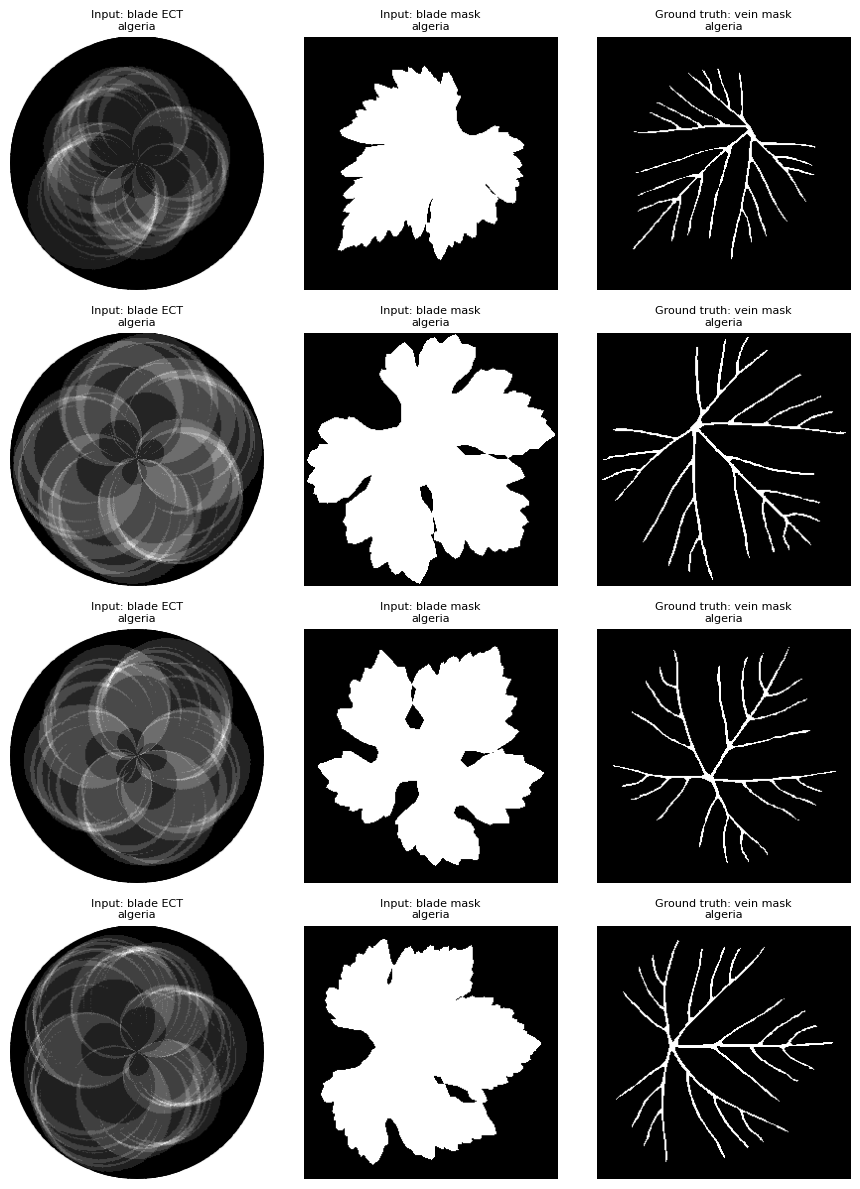

Valid samples: 480 | classes: 5


In [ ]:
valid = metadata_df[metadata_df.is_processed_valid].reset_index(drop=True)
fig, axes = plt.subplots(4, 3, figsize=(9, 12))
for r in range(4):
    row = valid.iloc[r]
    for c, (col, title, cm) in enumerate([("file_blade_ect", "Input: blade ECT", "gray"),
                                          ("file_blade_mask", "Input: blade mask", "gray"),
                                          ("file_vein_mask", "Ground truth: vein mask", "gray")]):
        axes[r, c].imshow(np.array(Image.open(SYNTH_DIR / row[col])), cmap=cm)
        axes[r, c].set_title(f"{title}\n{row.class_label}", fontsize=8)
        axes[r, c].axis("off")
plt.tight_layout(); plt.show()
print("Valid samples:", len(valid), "| classes:", valid.class_label.nunique())

## 4. U-Net training — authors' script 2 (ported)

The dataset loads, per sample, the 2-channel input (blade ECT, blade mask, each /255) and the vein mask target. The U-Net is the authors' exact architecture (4 down/up stages, bilinear upsampling, batch-norm double convs, 1×1 output head). Loss: equally weighted BCE-with-logits + Dice. Optimizer: Adam, lr 5e-4, batch 16, 80/20 train/validation split (seed 42), model selected by best validation Dice.

**ADAPTATION:** `NUM_EPOCHS = 8` (authors: 100). The paper reports peak validation **Dice 0.583** at 100 epochs with 400 leaves/class; this 8-epoch/480-leaf demo will land clearly below that — it demonstrates the pipeline and the learning trend, not the published metric.

**Japanese:** script 2 を移植：2 チャンネル入力（葉身 ECT + 葉身マスク）から葉脈マスクを予測する U-Net を、BCE + Dice の複合損失・Adam lr 5e-4・batch 16・80/20 分割（seed 42）で学習します。**適応：** 実行時間確保のためエポック数を 100 → 8 に減らしています（論文の 0.583 は 100 エポック・400 枚/クラスの値）。

In [ ]:
# --- Dataset and U-Net (ported from yemeen/ectnet synthetic_vein_prediction/scripts/2_train_unet.py) ---
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm

GLOBAL_RANDOM_SEED = 42  # (script 2)
BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, VALIDATION_SPLIT_RATIO = 16, 8, 0.0005, 0.2  # ADAPTATION: 100 -> 8 epochs
NUM_WORKERS = 0

def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class SyntheticLeafDataset(Dataset):
    def __init__(self, metadata_file, base_dir):
        self.metadata_df = pd.read_csv(metadata_file)
        self.metadata_df = self.metadata_df[self.metadata_df["is_processed_valid"]].reset_index(drop=True)
        self.base_dir = base_dir
        if self.metadata_df.empty:
            raise ValueError("No valid processed samples found.")
        print(f"Loaded {len(self.metadata_df)} valid synthetic samples for training.")

    def __len__(self):
        return len(self.metadata_df)

    def __getitem__(self, idx):
        row = self.metadata_df.iloc[idx]
        blade_ect_np = np.array(Image.open(self.base_dir / row["file_blade_ect"]).convert("L")) / 255.0
        blade_mask_np = np.array(Image.open(self.base_dir / row["file_blade_mask"]).convert("L")) / 255.0
        vein_mask_np = np.array(Image.open(self.base_dir / row["file_vein_mask"]).convert("L")) / 255.0
        inputs_tensor = torch.from_numpy(np.stack([blade_ect_np, blade_mask_np], axis=0)).float()
        target_tensor = torch.from_numpy(vein_mask_np).float().unsqueeze(0)
        return inputs_tensor, target_tensor

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_channels, out_channels))
    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)
    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY, diffX = x2.size()[2] - x1.size()[2], x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        return self.conv(torch.cat([x2, x1], dim=1))

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels_in, n_classes_out, bilinear=True):
        super().__init__()
        self.inc = DoubleConv(n_channels_in, 64)
        self.down1, self.down2 = Down(64, 128), Down(128, 256)
        self.down3, self.down4 = Down(256, 512), Down(512, 1024 // (2 if bilinear else 1))
        self.up1 = Up(1024, 512 // (2 if bilinear else 1), bilinear)
        self.up2 = Up(512, 256 // (2 if bilinear else 1), bilinear)
        self.up3 = Up(256, 128 // (2 if bilinear else 1), bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes_out)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.down1(x1); x3 = self.down2(x2); x4 = self.down3(x3); x5 = self.down4(x4)
        x = self.up1(x5, x4); x = self.up2(x, x3); x = self.up3(x, x2); x = self.up4(x, x1)
        return self.outc(x)

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__(); self.smooth = smooth
    def forward(self, inputs, targets):
        inputs, targets = inputs.view(-1), targets.view(-1)
        intersection = (inputs * targets).sum()
        return 1 - (2.0 * intersection + self.smooth) / (inputs.sum() + targets.sum() + self.smooth)

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.bce, self.dice = nn.BCEWithLogitsLoss(), DiceLoss()
        self.bce_weight, self.dice_weight = bce_weight, dice_weight
    def forward(self, inputs, targets):
        return self.bce_weight * self.bce(inputs, targets) + self.dice_weight * self.dice(torch.sigmoid(inputs), targets)

def calculate_dice_coefficient(predictions, targets, smooth=1e-6):
    predictions = (predictions > 0.5).float().view(-1)
    targets = targets.view(-1)
    intersection = (predictions * targets).sum()
    return ((2.0 * intersection + smooth) / (predictions.sum() + targets.sum() + smooth)).item()

print("Dataset / UNet / losses defined (ported from script 2).")

Dataset / UNet / losses defined (ported from script 2).


### Train the U-Net

Run the authors' training loop on the 480-leaf dataset: 80/20 split with seed 42, combined BCE + Dice loss, Adam (lr 5e-4), batch 16, model checkpointed whenever validation Dice improves, and the history saved to CSV. Progress bars print per epoch; the whole loop should take a few minutes on a T4.

**Japanese:** 著者の学習ループを実行します（80/20 分割・seed 42・BCE+Dice 損失・Adam lr 5e-4・batch 16、検証 Dice 改善時にチェックポイント保存、履歴は CSV に保存）。T4 で数分です。

In [ ]:
# --- Training loop (ported from script 2's train_model) ---
set_seed(GLOBAL_RANDOM_SEED)
dataset = SyntheticLeafDataset(SYNTH_DIR / "synthetic_metadata.csv", SYNTH_DIR)
train_size = int((1 - VALIDATION_SPLIT_RATIO) * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(GLOBAL_RANDOM_SEED))
dataloaders = {
    "train": DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS),
    "val": DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}
print(f"Training samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

model = UNet(n_channels_in=2, n_classes_out=1).to(DEVICE)
criterion = CombinedLoss(bce_weight=0.5, dice_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

MODEL_SAVE_PATH = Path("/content/ectnet_run/unet_model_results/trained_leaf_segmentation_model.pth")
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
best_dice, val_dice_history, train_loss_history = -1.0, [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, targets in tqdm(dataloaders["train"], desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_train_loss = running_loss / len(dataloaders["train"].dataset)

    model.eval()
    running_val_loss, running_val_dice = 0.0, 0.0
    with torch.no_grad():
        for inputs, targets in dataloaders["val"]:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            dice = calculate_dice_coefficient(torch.sigmoid(outputs), targets)
            running_val_loss += loss.item() * inputs.size(0)
            running_val_dice += dice * inputs.size(0)
    epoch_val_loss = running_val_loss / len(dataloaders["val"].dataset)
    epoch_val_dice = running_val_dice / len(dataloaders["val"].dataset)
    val_dice_history.append(epoch_val_dice)
    train_loss_history.append(epoch_train_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  train loss {epoch_train_loss:.4f} | "
          f"val loss {epoch_val_loss:.4f} | val Dice {epoch_val_dice:.4f}")
    if epoch_val_dice > best_dice:
        best_dice = epoch_val_dice
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"Best validation Dice: {best_dice:.4f} (paper reference: 0.583 after 100 epochs, 400 leaves/class)")
import pandas as pd
pd.DataFrame({"Epoch": range(1, len(val_dice_history) + 1),
              "Validation_Dice": val_dice_history,
              "Train_Loss": train_loss_history}).to_csv(
    "/content/ectnet_run/validation_dice_history.csv", index=False)

Loaded 480 valid synthetic samples for training.
Training samples: 384 | Validation samples: 96


Epoch 1/8:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/8  train loss 0.6735 | val loss 1.1286 | val Dice 0.0054


Epoch 2/8:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 2/8  train loss 0.6034 | val loss 0.6081 | val Dice 0.0000


...

Epoch 6/8  train loss 0.5312 | val loss 0.5280 | val Dice 0.2892


Epoch 7/8:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 7/8  train loss 0.5186 | val loss 0.5127 | val Dice 0.2050


Epoch 8/8:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 8/8  train loss 0.5106 | val loss 0.5090 | val Dice 0.1544
Best validation Dice: 0.2892 (paper reference: 0.583 after 100 epochs, 400 leaves/class)


### Learning curve

Validation Dice per epoch (authors' metric, script 2's `validation_dice_history.csv`). The paper's 100-epoch run plateaus near 0.57–0.58; this reduced 8-epoch demo shows the same metric rising from scratch on ~10× fewer leaves.

**Japanese:** 学習曲線：エポックごとの検証 Dice。論文（100 エポック、400 枚/クラス）では 0.57–0.58 に漸近します。

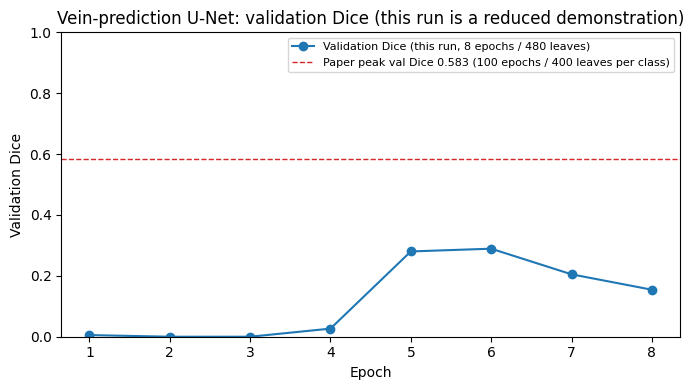

,Epoch,Validation_Dice,Train_Loss
0,1,5.386762e-03,0.673475
1,2,1.546863e-11,0.603433
2,3,1.670176e-11,0.575915
3,4,2.660743e-02,0.557876
4,5,2.801728e-01,0.542566
5,6,2.892213e-01,0.531240
6,7,2.050462e-01,0.518612
7,8,1.543900e-01,0.510620


In [ ]:
import pandas as pd
hist = pd.read_csv("/content/ectnet_run/validation_dice_history.csv")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist["Epoch"], hist["Validation_Dice"], "o-", color="tab:blue", label="Validation Dice (this run, 8 epochs / 480 leaves)")
ax.axhline(0.583, color="tab:red", ls="--", lw=1, label="Paper peak val Dice 0.583 (100 epochs / 400 leaves per class)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Dice"); ax.set_ylim(0, 1)
ax.set_title("Vein-prediction U-Net: validation Dice (this run is a reduced demonstration)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
hist

## 5. Prediction and TP/FP/FN evaluation — authors' script 3 (ported)

Inference on validation leaves with the best saved model, then the paper's error map: **white = true positives, magenta = false positives, dodgerblue = false negatives, gray = background**, with the blade outline overlaid (script 3's palette and its 90°+180° coordinate rotation for the outline). The first panel shows the model input (blade ECT with the blade outline, as in Figure 7's left column).

**Japanese:** ベストモデルで検証データに推論し、論文 Figure 7 と同じ TP（白）／FP（マゼンタ）／FN（青）の誤差マップを作成します。左列は入力である葉身 ECT と葉身輪郭です。

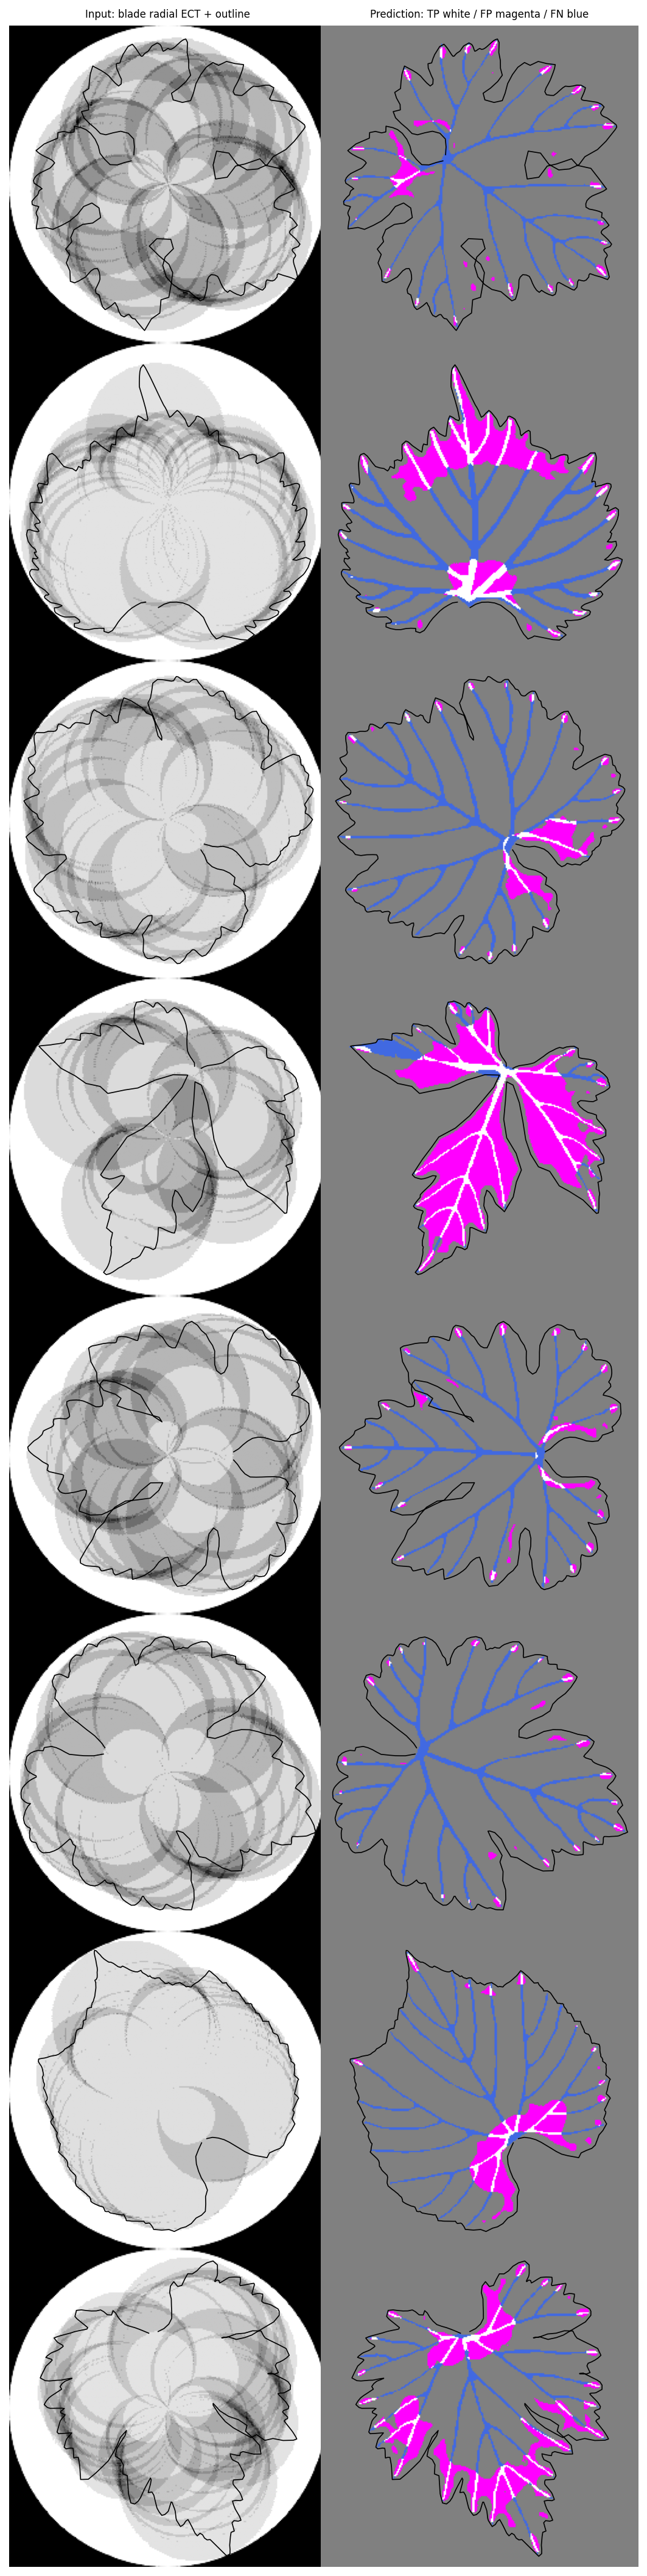

In [ ]:
# --- Inference + figure (ported from script 3; 8 leaves instead of 40) ---
import random
def set_seed_figure(seed=7):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed_figure(7)
NUM_FIGURE_SAMPLES = 8  # ADAPTATION: authors use 40

inference_model = UNet(n_channels_in=2, n_classes_out=1).to(DEVICE)
inference_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
inference_model.eval()

valid_md = pd.read_csv(SYNTH_DIR / "synthetic_metadata.csv")
valid_md = valid_md[valid_md.is_processed_valid].reset_index(drop=True)
val_ids = set(int(i) for i in val_dataset.indices)
candidates = [idx for idx, sid in enumerate(valid_md.synthetic_id) if int(sid.split("_")[-1]) in val_ids]
selected = random.sample(candidates, min(NUM_FIGURE_SAMPLES, len(candidates)))

BACKGROUND_COLOR, TP_COLOR, FP_COLOR, FN_COLOR = [128,128,128], [255,255,255], [255,0,255], [65,105,225]

fig, axes = plt.subplots(len(selected), 2, figsize=(7, len(selected) * 3.5), dpi=150)
with torch.no_grad():
    for r, idx in enumerate(selected):
        row = valid_md.iloc[idx]
        blade_ect = np.array(Image.open(SYNTH_DIR / row.file_blade_ect).convert("L")) / 255.0
        blade_mask = np.array(Image.open(SYNTH_DIR / row.file_blade_mask).convert("L")) / 255.0
        gt = np.array(Image.open(SYNTH_DIR / row.file_vein_mask).convert("L")) / 255.0
        blade_coords = np.load(SYNTH_DIR / row.file_transformed_blade_coords)
        inputs_t = torch.from_numpy(np.stack([blade_ect, blade_mask], axis=0)).float().unsqueeze(0).to(DEVICE)
        pred = (torch.sigmoid(inference_model(inputs_t)) > 0.5).float().squeeze().cpu().numpy()

        # blade outline: script 3's 90deg CCW then 180deg rotation of transformed coords
        final_x = blade_coords[:, 1]; final_y = -blade_coords[:, 0]
        px = final_x * (IMAGE_SIZE[0] / 2) + IMAGE_SIZE[0] / 2
        py = final_y * (IMAGE_SIZE[1] / 2) + IMAGE_SIZE[1] / 2

        ax_l = axes[r, 0]
        ax_l.imshow(blade_ect, cmap="gray_r")
        ax_l.plot(px, py, color="black", linewidth=0.8, zorder=10)
        ax_l.axis("off")
        if r == 0: ax_l.set_title("Input: blade radial ECT + outline", fontsize=8)

        composite = np.full((*gt.shape, 3), BACKGROUND_COLOR, dtype=np.uint8)
        gt_b, pred_b = gt == 1, pred == 1
        composite[gt_b & ~pred_b] = FN_COLOR
        composite[~gt_b & pred_b] = FP_COLOR
        composite[gt_b & pred_b] = TP_COLOR
        ax_r = axes[r, 1]
        ax_r.imshow(composite)
        ax_r.plot(px, py, color="black", linewidth=0.8, zorder=10)
        ax_r.axis("off")
        if r == 0: ax_r.set_title("Prediction: TP white / FP magenta / FN blue", fontsize=8)

plt.tight_layout(pad=0.0)
plt.savefig("/content/ectnet_run/synthetic_vein_predictions_figure.png", bbox_inches="tight", pad_inches=0.0)
plt.show()

### Quantitative validation summary

Per-epoch metrics (saved to CSV inside the Colab VM) plus the final best validation Dice, compared with the paper's reference value. This single reduced run is a **demonstration, not a verification** of the paper's published dataset-level performance.

**Japanese:** 定量結果の要約。best 検証 Dice と論文参照値（0.583）を併記します。削減デモであり、論文のデータセット規模の結果の検証ではありません。

In [ ]:
hist = pd.read_csv("/content/ectnet_run/validation_dice_history.csv")
summary = {
    "samples_generated": int(len(valid_md)),
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "epochs": NUM_EPOCHS,
    "best_validation_dice": round(best_dice, 4),
    "final_validation_dice": round(hist.Validation_Dice.iloc[-1], 4),
    "paper_reference_val_dice_100ep": 0.583,
    "device": str(DEVICE),
}
for k, v in summary.items():
    print(f"{k}: {v}")
hist

samples_generated: 480
train_samples: 384
validation_samples: 96
epochs: 8
best_validation_dice: 0.2892
final_validation_dice: 0.1544
paper_reference_val_dice_100ep: 0.583
device: cuda


,Epoch,Validation_Dice,Train_Loss
0,1,5.386762e-03,0.673475
1,2,1.546863e-11,0.603433
2,3,1.670176e-11,0.575915
3,4,2.660743e-02,0.557876
4,5,2.801728e-01,0.542566
5,6,2.892213e-01,0.531240
6,7,2.050462e-01,0.518612
7,8,1.543900e-01,0.510620


## 6. Interpretation and limitations

**What this shows.** The authors' pipeline generates balanced synthetic grapevine leaves from a bundled GPA/PCA model of real leaves (SMOTE-like interpolation within genotype classes), encodes each blade as a radial ECT, and a two-channel U-Net trained **only** on blade geometry (ECT + mask) predicts the vein mask — the paper's argument that the blade contains sufficient information for venation (developmental constraint; Figure 7).

**Differences from the paper / limitations** / **論文との違い・限界:**
- **Reduced scale:** ~480 synthetic leaves (authors: 400 per class) and 8 epochs (authors: 100); the validation Dice here is expected to be below the reported 0.583 plateau.
- **Step 0 skipped:** the GPA/PCA fit is taken from the authors' committed model outputs rather than re-fitted from `data.zip`.
- **Vein ECT / QC composites omitted** per leaf (unused by training/inference; a runtime optimization).
- **Not verified:** dataset-level classification results (Figures 3–5), the 4-million-leaf herbarium experiment, ECT-to-shape inversion (Figure 6) — out of scope for this notebook.
- The `ectnet` repository declares no license; this notebook runs the code but does not redistribute it.

**Provenance:** paper doi:10.64898/2026.04.13.718293 (bioRxiv v1); code `yemeen/ectnet` @ `9cdff8d6d2f4f60489c192ada1b92d198eceae48` (`synthetic_vein_prediction/scripts/1..3`); inputs verified by Git blob SHA-1 in Colab. Paper methods were cross-checked against the pinned code; the PhenoPaper investigation/flow (reviewStatus: unverified) was used only as guidance.

**References:**
1. bioRxiv preprint doi:10.64898/2026.04.13.718293 — *The Euler Characteristic Transform Enables Classification of Complex Plant Shapes and Prediction of Leaf Venation from Blade Geometry* (2026).
2. `yemeen/ectnet`, commit `9cdff8d6d2f4f60489c192ada1b92d198eceae48`, `synthetic_vein_prediction/`.
3. `ect` Python package (PyPI), MunchLab — https://github.com/MunchLab/ect.